In [1]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# 2. List all files in folder
for dirname, _, filenames in os.walk('inputs'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

inputs\comments.csv
inputs\follows.csv
inputs\likes.csv
inputs\photos.csv
inputs\photo_tags.csv
inputs\tags.csv
inputs\users.csv


In [4]:
# 3. Get file names list
dest_path = 'inputs'
file_names = os.listdir(dest_path)
file_names

['comments.csv',
 'follows.csv',
 'likes.csv',
 'photos.csv',
 'photo_tags.csv',
 'tags.csv',
 'users.csv']

In [5]:
import pandas as pd

users = pd.read_csv('inputs/users.csv')
photos = pd.read_csv('inputs/photos.csv')
likes = pd.read_csv('inputs/likes.csv')
comments = pd.read_csv('inputs/comments.csv')
follows = pd.read_csv('inputs/follows.csv')

In [6]:
# 5. Preprocess Data

df = users.copy()

# Count likes per user
likes_count = likes.groupby('user_id').size().reset_index(name='total_likes')

# Count comments per user
comments_count = comments.groupby('user_id').size().reset_index(name='total_comments')

# Merge data
df = df.merge(likes_count, left_on='id', right_on='user_id', how='left')
df = df.merge(comments_count, left_on='id', right_on='user_id', how='left')

df = df.fillna(0)

# Engagement feature
df['engagement'] = df['total_likes'] + df['total_comments']




In [7]:
# 6. Simple Rule-Based Prediction (Weak Model)

likes_input = int(input("Enter number of likes: "))
comments_input = int(input("Enter number of comments: "))

engagement = likes_input + comments_input

threshold = df['engagement'].median()

if engagement > threshold:
    print("Prediction (Without ML): Influencer")
else:
    print("Prediction (Without ML): Not Influencer")

Prediction (Without ML): Influencer


In [8]:
# 7. Train ML Model

# Create label
df['influencer'] = df['engagement'].apply(
    lambda x: 1 if x > df['engagement'].median() else 0
)

X = df[['total_likes', 'total_comments']]
y = df['influencer']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Model Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [9]:
# 8. Prediction using ML Model

likes_input = int(input("Enter number of likes: "))
comments_input = int(input("Enter number of comments: "))

input_data = [[likes_input, comments_input]]

prediction = model.predict(input_data)

if prediction[0] == 1:
    print("Prediction (With ML): Influencer")
else:
    print("Prediction (With ML): Not Influencer")

Prediction (With ML): Not Influencer


c:\Users\kisho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [10]:
# Followers count
followers_count = follows.groupby('followee_id').size().reset_index(name='followers')

# Posts count
posts_count = photos.groupby('user_id').size().reset_index(name='posts')

# Likes per user (via photos)
likes_merged = likes.merge(photos, left_on='photo_id', right_on='id')
likes_count = likes_merged.groupby('user_id_y').size().reset_index(name='likes')
likes_count.rename(columns={'user_id_y': 'user_id'}, inplace=True)

# Comments per user (via photos)
comments_merged = comments.merge(photos, left_on='photo_id', right_on='id')
comments_count = comments_merged.groupby('user_id_y').size().reset_index(name='comments')
comments_count.rename(columns={'user_id_y': 'user_id'}, inplace=True)

# --- Merge all FIRST ---
df2 = users.copy()

df2 = df2.merge(followers_count, left_on='id', right_on='followee_id', how='left')
df2 = df2.merge(posts_count, left_on='id', right_on='user_id', how='left')
df2 = df2.merge(likes_count, left_on='id', right_on='user_id', how='left')
df2 = df2.merge(comments_count, left_on='id', right_on='user_id', how='left')

df2 = df2.fillna(0)

# --- THEN create features ---
df2['likes_per_post'] = df2['likes'] / (df2['posts'] + 1)
df2['comments_per_post'] = df2['comments'] / (df2['posts'] + 1)

# Optional: remove extreme outliers
df2 = df2[df2['likes_per_post'] < df2['likes_per_post'].quantile(0.99)]
df2 = df2[df2['comments_per_post'] < df2['comments_per_post'].quantile(0.99)]

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Features
X = df2[['followers', 'posts']]

# Targets
y_likes = df2['likes_per_post']
y_comments = df2['comments_per_post']

# Split data
X_train, X_test, yL_train, yL_test = train_test_split(X, y_likes, test_size=0.2, random_state=42)
_, _, yC_train, yC_test = train_test_split(X, y_comments, test_size=0.2, random_state=42)

# Train models
likes_model = RandomForestRegressor()
comments_model = RandomForestRegressor()

likes_model.fit(X_train, yL_train)
comments_model.fit(X_train, yC_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [13]:
followers_input = int(input("Enter followers: "))
posts_input = int(input("Enter total posts: "))

input_data = [[followers_input, posts_input]]

pred_likes = likes_model.predict(input_data)
pred_comments = comments_model.predict(input_data)

print("Predicted Likes per Post:", max(50, int(pred_likes[0])))
print("Predicted Comments per Post:", max(2, int(pred_comments[0])))

Predicted Likes per Post: 50
Predicted Comments per Post: 2


c:\Users\kisho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\kisho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


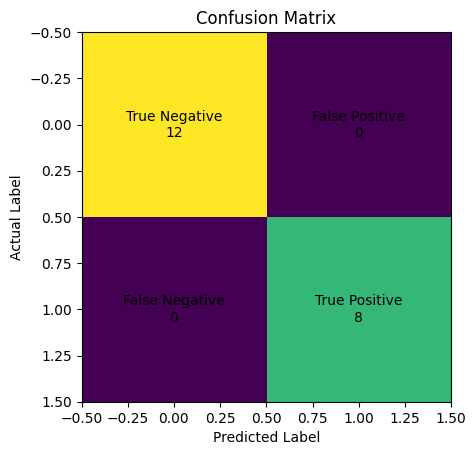

In [14]:
# Confusion Matrix (Labeled - No Color Styling)

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Labels mapping
labels = [["True Negative", "False Positive"],
          ["False Negative", "True Positive"]]

# Add text inside each box
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{labels[i][j]}\n{cm[i][j]}",
                 ha='center', va='center')

plt.show()

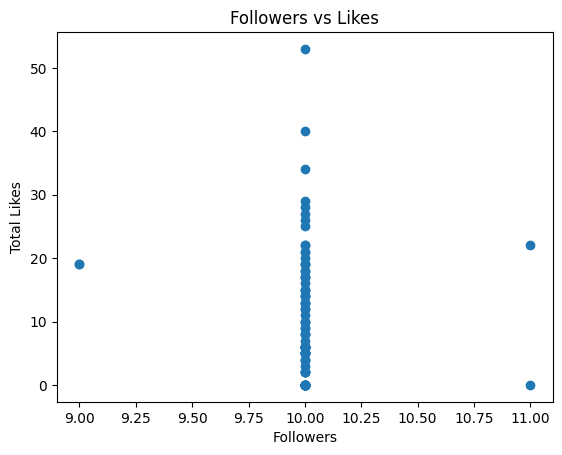

In [15]:
plt.figure()
plt.scatter(df2['followers'], df2['likes'])
plt.xlabel("Followers")
plt.ylabel("Total Likes")
plt.title("Followers vs Likes")
plt.show()

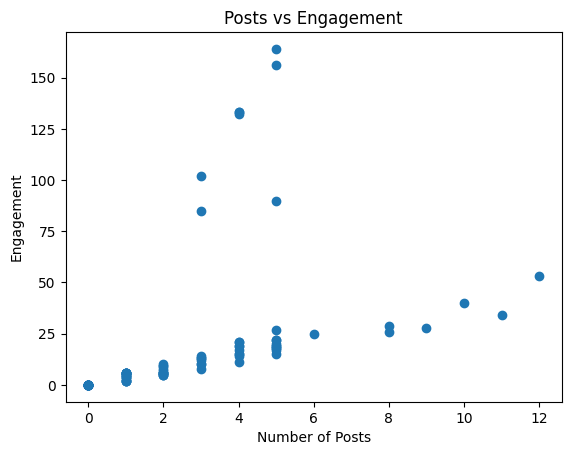

In [16]:
df2['engagement'] = df2['likes'] + df2['comments']

plt.figure()
plt.scatter(df2['posts'], df2['engagement'])
plt.xlabel("Number of Posts")
plt.ylabel("Engagement")
plt.title("Posts vs Engagement")
plt.show()